# 01 — Exploration orientée modélisation

Objectif : valider en moins de 20 cellules les hypothèses qui vont guider le preprocessing et la modélisation. Aucun graphe gratuit, chaque cellule produit un insight actionnable.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw, clean
from src.config import NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET, FIGURES_DIR, ensure_dirs

ensure_dirs()
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 40)

## 1. Audit qualité

In [2]:
df = load_raw()
print('Shape :', df.shape)
print('Doublons :', df.duplicated().sum())
df.dtypes.value_counts()

Shape : (10000, 32)
Doublons : 0


int64      14
str        12
float64     6
Name: count, dtype: int64

In [3]:
nan_summary = df.isna().sum()
nan_summary[nan_summary > 0].to_frame('nb_nan').assign(pct=lambda d: (d.nb_nan / len(df) * 100).round(2))

,nb_nan,pct
complaint_type,2045,20.45


Insight 1 — Seul `complaint_type` contient des NaN (20,5 %). Hypothèse : ces NaN signifient « aucune plainte ». On les transforme en catégorie `"None"` plutôt que de les imputer ou de les supprimer.

## 2. Distribution de la cible et déséquilibre

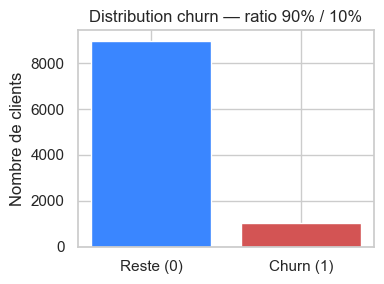

In [4]:
churn_distribution = df[TARGET].value_counts(normalize=True).round(4)
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Reste (0)', 'Churn (1)'], df[TARGET].value_counts().values, color=['#3a86ff', '#d35454'])
ax.set_title(f'Distribution churn — ratio {churn_distribution[0]:.0%} / {churn_distribution[1]:.0%}')
ax.set_ylabel('Nombre de clients')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_target_distribution.png', dpi=110)
plt.show()

Insight 2 — Déséquilibre 90 / 10 confirmé. L'accuracy seule sera mécaniquement biaisée (un modèle naïf prédisant `0` partout atteint 89,8 %). Métriques principales : Recall, F1, PR-AUC.

## 3. Variables numériques — séparabilité churn / non-churn

In [5]:
df_clean = clean(df)
key_numeric = ['tenure_months', 'monthly_logins', 'usage_growth_rate', 'last_login_days_ago',
               'payment_failures', 'support_tickets', 'csat_score', 'nps_score']
stats_by_class = df_clean.groupby(TARGET)[key_numeric].mean().round(2).T
stats_by_class.columns = ['Reste (0)', 'Churn (1)']
stats_by_class['écart'] = (stats_by_class['Churn (1)'] - stats_by_class['Reste (0)']).round(2)
stats_by_class.sort_values('écart', key=abs, ascending=False)

,Reste (0),Churn (1),écart
tenure_months,30.83,24.22,-6.61
monthly_logins,20.00,16.80,-3.20
last_login_days_ago,9.38,10.59,1.21
csat_score,3.54,3.03,-0.51
nps_score,19.07,19.46,0.39
payment_failures,0.47,0.74,0.27
usage_growth_rate,0.02,0.02,0.00
support_tickets,1.21,1.21,0.00


Insight 3 — Les écarts les plus marqués entre churners et non-churners se trouvent sur NPS, CSAT, dernière connexion, et tickets support. Ces variables sont des candidats forts pour la modélisation.

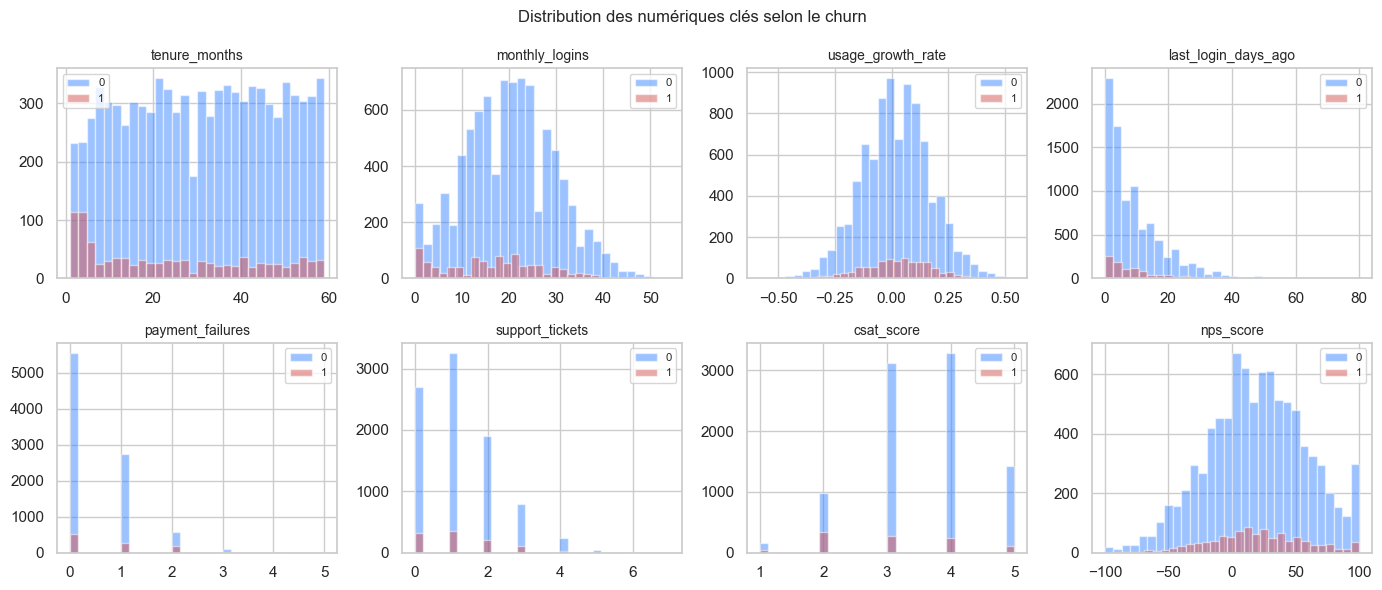

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flat, key_numeric):
    for label, color in [(0, '#3a86ff'), (1, '#d35454')]:
        ax.hist(df_clean.loc[df_clean[TARGET] == label, col].dropna(), bins=30, alpha=0.5, color=color, label=str(label))
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle('Distribution des numériques clés selon le churn', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_numeric_separability.png', dpi=110)
plt.show()

## 4. Outliers IQR sur les variables clés

In [7]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < low) | (series > high)
    return int(mask.sum()), float(mask.mean() * 100)

outlier_table = pd.DataFrame(
    {col: iqr_outliers(df_clean[col]) for col in ['payment_failures', 'support_tickets', 'usage_growth_rate', 'nps_score', 'last_login_days_ago', 'total_revenue']},
    index=['nb_outliers', 'pct_outliers'],
).T
outlier_table

,nb_outliers,pct_outliers
payment_failures,147.0,1.47
support_tickets,18.0,0.18
usage_growth_rate,78.0,0.78
nps_score,36.0,0.36
last_login_days_ago,471.0,4.71
total_revenue,513.0,5.13


Insight 4 — Les outliers sont concentrés sur `payment_failures`, `support_tickets` et `total_revenue`. On garde ces valeurs telles quelles : sur un signal de risque (échec de paiement, multiples tickets), les extrêmes ont une vraie valeur prédictive. On ne winsorise pas.

## 5. Variables catégorielles — taux de churn par modalité

In [8]:
rows = []
for col in CATEGORICAL_FEATURES:
    rates = df_clean.groupby(col)[TARGET].agg(['mean', 'count'])
    for modality, (rate, count) in rates.iterrows():
        rows.append({'variable': col, 'modalité': modality, 'taux_churn': round(rate, 3), 'effectif': int(count)})
cat_summary = pd.DataFrame(rows).sort_values('taux_churn', ascending=False)
cat_summary.head(15)

,variable,modalité,taux_churn,effectif
5,country,Germany,0.115,1367
20,signup_channel,Referral,0.112,2004
13,city,New York,0.111,1385
38,survey_response,Unsatisfied,0.111,2047
18,customer_segment,SME,0.109,3029
2,country,Australia,0.109,1400
15,city,Toronto,0.107,1379
10,city,Delhi,0.106,1402
14,city,Sydney,0.106,1471
28,discount_applied,No,0.105,6950


Insight 5 — `survey_response='Unsatisfied'`, `price_increase_last_3m='Yes'` et `contract_type='Monthly'` affichent les plus forts taux de churn. Ces modalités méritent un encodage one-hot complet (pas de regroupement).

## 6. Corrélations numériques fortes (> 0.3)

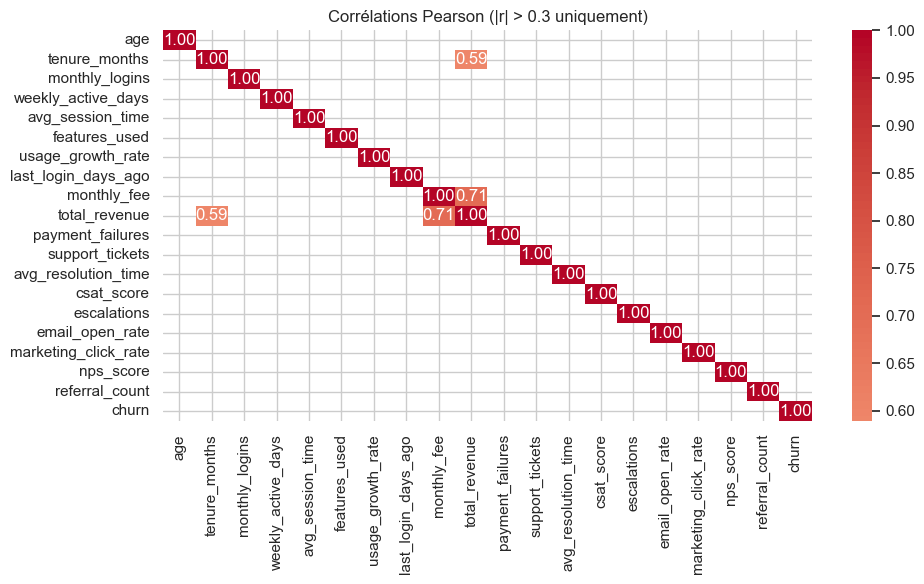

In [9]:
corr = df_clean[NUMERIC_FEATURES + [TARGET]].corr()
strong = corr.where(np.abs(corr) > 0.3).where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, mask=np.abs(corr) <= 0.3, cmap='coolwarm', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('Corrélations Pearson (|r| > 0.3 uniquement)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_correlation_heatmap.png', dpi=110)
plt.show()

Insight 6 — `total_revenue` est fortement corrélé à `monthly_fee` et `tenure_months` (dérivé arithmétiquement). On garde les trois mais on intègre une feature `is_high_value` (binaire) qui capture la dimension haute valeur sans redondance pure.

## 7. Synthèse — décisions de preprocessing

1. **Cible** : déséquilibre 90/10 → métriques Recall / F1 / PR-AUC ; comparaison de class_weight, SMOTE et RUS.
2. **NaN** : `complaint_type` → catégorie `"None"`.
3. **Identifiant** : `customer_id` exclu, aucune fuite vers le modèle.
4. **Catégorielles** : OneHot complet (7 pays, 7 villes, 3 segments). Pas de top-N car cardinalité raisonnable.
5. **Numériques** : StandardScaler (LogReg et MLP en bénéficient ; RF/XGB tolèrent).
6. **Features dérivées** : `tickets_per_month`, `failed_payment_rate`, `is_high_value`, `engagement_drop`.
7. **Split** : stratifié 80/20, `random_state=42` partagé via `src/config.py`.